# Email Spam Classifier

This notebook builds a machine-learning model that classifies emails as **spam** or **ham**.
It uses `CountVectorizer` for text representation and `MultinomialNB` for classification.

## 1. Import Libraries


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## 2. Load and Explore the Dataset


In [ ]:
df_spam=pd.read_csv("email_dataset_100k.csv")
(df_spam.head(10))

In [ ]:
type(df_spam)

In [4]:
df_spam["label"].value_counts(normalize=True)

label
0    0.5
1    0.5
Name: proportion, dtype: float64

In [5]:
df_spam.shape

(100000, 30)

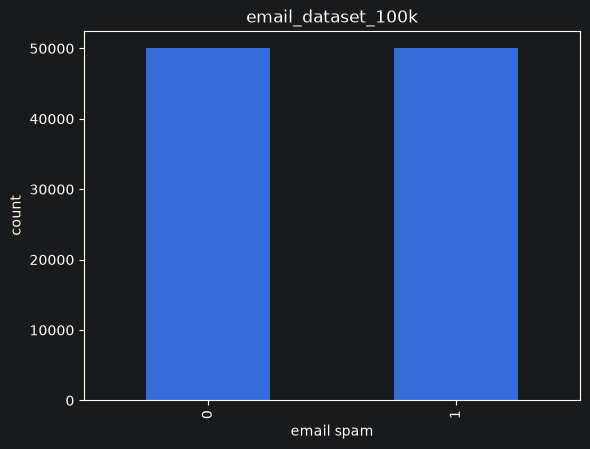

In [6]:
df_spam["label"].value_counts().plot(kind="bar")
plt.title("email_dataset_100k")
plt.xlabel("email spam")
plt.ylabel("count")
plt.show()

In [7]:
import sklearn
print(sklearn.__version__)

1.9.0


## 3. Prepare the Data


In [ ]:
X=df_spam["raw_text"]
y=df_spam["label"]
print(X.head())
print(y.head())

In [9]:
X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train",X_train.shape)
print("y_train",y_train.shape)
print("X_test",X_test.shape)
print("y_test",y_test.shape)

X_train (80000,)
y_train (80000,)
X_test (20000,)
y_test (20000,)


## 4. Build and Train the Model


In [ ]:
model_nb = Pipeline([
    ("Vectorizer", CountVectorizer()),
    ("classifier", MultinomialNB()),
])
model_nb.fit(X_train,y_train);


## 5. Evaluate the Model


In [ ]:
y_pred = model_nb.predict(X_test)
y_pred[:10]

In [ ]:
comparison = pd.DataFrame({
    "email": X_test,
    "real_label": y_test,
    "predicted_label": y_pred
})
comparison.sample(20)

In [13]:
wrong_predictions = comparison[
    comparison["real_label"] != comparison["predicted_label"]
]
wrong_predictions[:10]
wrong_predictions.shape[0]

0

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy {accuracy:.2%}")

accuracy 100.00%


In [18]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["ham","spam"]
))

              precision    recall  f1-score   support

         ham       1.00      1.00      1.00     10000
        spam       1.00      1.00      1.00     10000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



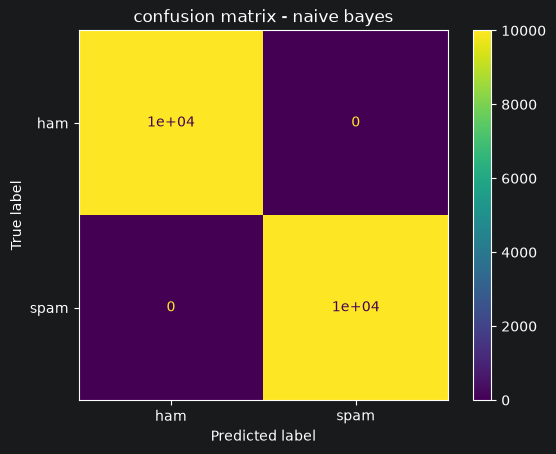

In [21]:
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ham","spam"]
)
display.plot()
plt.title("confusion matrix - naive bayes")
plt.show()

In [ ]:
comparison["is correct"]= (
    comparison["real_label"] == comparison["predicted_label"]
)
comparison.head(10)

## 6. Test with New Emails

The current run reports perfect performance on the held-out set. Because perfect scores can occur with synthetic, unusually simple, duplicated, or leaked data, this result should be validated before it is treated as an estimate of real-world performance.

The trained pipeline is tested on a few new email examples to show how predictions can be produced.


In [23]:
new_emails = [
    "Congratulations! You won a free iPhone. Click here to claim your prize.",

    "Hi Sarah, the project meeting will be tomorrow at 10 AM.",

    "URGENT! Confirm your bank account now to avoid suspension.",

    "Hello, I attached the notes from today's class."
]

In [ ]:
new_predictions = model_nb.predict(new_emails)

new_predictions

In [25]:
for email, prediction in zip(new_emails, new_predictions):

    if prediction == 1:
        result = "Spam"
    else:
        result = "Ham"

    print("Email:", email)
    print("Prediction:", result)
    print("-" * 50)

Email: Congratulations! You won a free iPhone. Click here to claim your prize.
Prediction: Spam
--------------------------------------------------
Email: Hi Sarah, the project meeting will be tomorrow at 10 AM.
Prediction: Ham
--------------------------------------------------
Email: URGENT! Confirm your bank account now to avoid suspension.
Prediction: Spam
--------------------------------------------------
Email: Hello, I attached the notes from today's class.
Prediction: Ham
--------------------------------------------------
